# Carbon metabolism flux distributions

FBA flux distributions for the 28 EMP/TCA/PPP reactions (`Carbon_metabolism_IDs.csv`) across
7 models (`iBsu1103`, `iBsu1103v2`, `iBsu1209` excluded), under M9 minimal media with glucose
uptake set to 7.63 mmol/gDW/h to match the experimental condition below. Reads from
`../data/models/02_final_annotated/`, the output of `001_standardization.ipynb`.

Experimental fluxes (Chubukov et al., 2013), also in `Carbon_metabolism_IDs.csv`, are included
as an `experimental_flux` column in the output table and plotted alongside the FBA bars. Every
model flux is reported in the pathway-forward direction so it is comparable with them (see
*Composite reactions* below).

Outputs: `../results/tables/carbon_metabolism_fluxes.csv` and
`../results/figures/carbon_metabolism_fluxes.pdf`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cobra.io import read_sbml_model
from cobra.flux_analysis import pfba

final_dir = os.path.join("..", "data", "models", "02_final_annotated")
# Canonical model order used throughout the manuscript
MODELS = ["iYO844", "iBsu1147", "eciYO844", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]

medium = pd.read_csv("../data/datasets/M9_media.csv")

# Match the experimental glucose uptake rate (Chubukov et al., 2013, GLCpts flux)
# instead of the default M9 bound, so FBA fluxes are comparable at the same substrate uptake.
GLUCOSE_UPTAKE = 7.63
medium.loc[medium["ID"] == "EX_glc__D_e", "LOWER_BOUND"] = -GLUCOSE_UPTAKE


def set_culture_media(model, media):
    """Apply the media bounds, closing any `_reverse` import partner.

    GECKO models bypass the medium cap entirely if those partners are left open: ecBSU1 was
    taking up 9.3 mmol/gDW/h of ammonia against an M9 cap of 5.
    """
    for _, row in media.iterrows():
        rxn_id = row["ID"]
        if rxn_id not in model.reactions:
            continue
        model.reactions.get_by_id(rxn_id).bounds = (row["LOWER_BOUND"], row["UPPER_BOUND"])

        reverse_id = f"{rxn_id}_reverse"
        if reverse_id in model.reactions:
            model.reactions.get_by_id(reverse_id).bounds = (0.0, 0.0)
    return model


models = {name: read_sbml_model(os.path.join(final_dir, f"{name}.xml")) for name in MODELS}
for model in models.values():
    set_culture_media(model, medium)
print(f"[INFO] Loaded {len(models)} models, M9 media applied")

Set parameter Username


Set parameter LicenseID to value 2695449


--------------------------------------------


--------------------------------------------


Academic license - for non-commercial use only - expires 2026-08-13


'' is not a valid SBML 'SId'.


'' is not a valid SBML 'SId'.


'' is not a valid SBML 'SId'.


[INFO] Loaded 7 models, M9 media applied


## Composite reactions

Most of the 28 reactions exist under their canonical id in `02_final_annotated/*.xml`. The rest are mapped below and aggregate one of two ways: **parallel** instances (isozymes, GECKO forward/reverse splits) sum as forward minus reverse, **series** steps sharing an intermediate average. Using the wrong rule doubles or halves the flux.

Every flux is re-oriented to the pathway-forward direction using the sign of the pathway product in each model's own equation. pFBA is used rather than plain FBA.

In [2]:
import re

# (model, canonical_id) -> (aggregation, [(forward_id, reverse_id), ...])
#   "parallel" - isozymes / forward-reverse splits running side by side: net = sum(fwd - rev)
#   "series"   - consecutive steps of one linear route: they all carry the same flux, so the
#                canonical reaction's flux is their mean, not their sum
COMPOSITE_REACTIONS = {
    ("ecBSU1", "PGI"): ("parallel", [("PGIA", "PGIA_reverse"), ("G6PI3", "G6PI3_reverse")]),
    ("ecBSU1", "FBA"): ("parallel", [("FBAf", "FBAf_reverse")]),
    ("ecBSU1", "TPI"): ("parallel", [("TPI_num1", "TPI_reverse_num1"), ("TPI_num2", "TPI_reverse_num2")]),
    # GAPDHf is GapA (NAD); GAPDi_nadp is GapB (NADP), which runs the opposite way here and
    # has to be subtracted or the glycolytic step reads 2.7 mmol/gDW/h too high.
    ("ecBSU1", "GAPD"): ("parallel", [("GAPDHf", "GAPDHf_reverse"), (None, "GAPDi_nadp")]),
    ("ecBSU1", "PGK"): ("parallel", [("PGKm", "PGKm_reverse")]),
    ("ecBSU1", "PGM"): ("parallel", [("PGM", "PGM_reverse")]),
    ("ecBSU1", "ENO"): ("parallel", [("ENOm", "ENOm_reverse")]),
    ("ecBSU1", "CS"): ("parallel", [("CS_num1", None), ("CS_num2", None)]),
    ("ecBSU1", "ACONT"): ("series", [("ACONTa", None), ("ACONTb_reverse", None)]),
    ("ecBSU1", "SUCOAS"): ("parallel", [("SUCOAS", "SUCOAS_reverse")]),
    ("ecBSU1", "SUCD1"): ("parallel", [("SUCD1", "SUCD1_reverse")]),
    ("ecBSU1", "FUM"): ("parallel", [("FUM", "FUM_reverse")]),
    ("ecBSU1", "MDH"): ("parallel", [("MDHm_num1", "MDHm_reverse_num1"), ("MDHm_num2", "MDHm_reverse_num2")]),
    ("ecBSU1", "G6PDH2r"): ("parallel", [("G6PBDH", "G6PBDH_reverse")]),
    ("ecBSU1", "PGL"): ("parallel", [("PGL", "PGL_reverse")]),
    ("ecBSU1", "GND"): ("parallel", [("GND_num1", None), ("GND_num2", None), ("GND_num3", None)]),
    ("ecBSU1", "RPI"): ("parallel", [("R01056", "R01056_reverse")]),
    ("ecBSU1", "RPE"): ("parallel", [("RPEh", "RPEh_reverse")]),
    ("ecBSU1", "TKT1"): ("parallel", [("R01641", "R01641_reverse")]),
    ("ecBSU1", "TKT2"): ("parallel", [("TKT2", "TKT2_reverse")]),
    ("ecBSU1", "TALA"): ("parallel", [("TALA", "TALA_reverse")]),
    ("iBsu1147", "PGI"): ("parallel", [("PGIA", None), ("G6PI3", None)]),
    ("iBsu1147", "ACONT"): ("series", [("ACONTa", None), (None, "ACONTb")]),
    ("iBsu1147", "ICDHyr"): ("series", [("r0423", None), ("r0082", None)]),
    # Pyruvate / 2-oxoglutarate dehydrogenase complexes, split into E1/E2/E3 half-reactions
    # around a lipoamide carrier; these are the acyl-CoA-releasing steps, written in reverse.
    ("iBsu1147", "PDH"): ("parallel", [(None, "PDHbr")]),
    ("iBsu1147", "AKGDH"): ("parallel", [(None, "AKGDb")]),
    ("iBsu1147R", "PGI"): ("parallel", [("PGIA", None), ("G6PI3", None)]),
    ("iBsu1147R", "ACONT"): ("series", [("ACONTa", None), (None, "ACONTb")]),
}

# Metabolite produced by each canonical reaction when it runs in the pathway-forward direction
# (glycolysis glucose -> pyruvate, TCA forward, PPP oxidative -> non-oxidative). The sign of this
# metabolite's stoichiometric coefficient in a given model says whether that model writes the
# reaction with or against the pathway, so fluxes can be put on a common footing.
PATHWAY_PRODUCT = {
    "GLCpts": "g6p", "PGI": "f6p", "PFK": "fdp", "FBA": "g3p", "TPI": "g3p",
    "GAPD": "13dpg", "PGK": "3pg", "PGM": "2pg", "ENO": "pep", "PYK": "pyr",
    "CS": "cit", "ACONT": "icit", "ICDHyr": "akg", "AKGDH": "succoa", "SUCOAS": "succ",
    "SUCD1": "fum", "FUM": "mal_L", "MDH": "oaa", "PDH": "accoa", "PC": "oaa",
    "G6PDH2r": "6pgl", "PGL": "6pgc", "GND": "ru5p_D", "RPI": "r5p", "RPE": "xu5p_D",
    "TKT1": "s7p", "TALA": "e4p", "TKT2": "f6p",
}


def safe_flux(solution, rxn_id):
    if rxn_id is None or solution is None:
        return 0.0
    val = solution.fluxes.get(rxn_id)
    if val is None or np.isnan(val):
        return 0.0
    return float(val)


def net_flux(solution, model_name, canonical_id):
    """Flux of a canonical reaction in the direction that model happens to write it."""
    entry = COMPOSITE_REACTIONS.get((model_name, canonical_id))
    if entry is None:
        return safe_flux(solution, canonical_id)  # renamed to canonical id, or genuinely absent -> 0
    aggregation, instances = entry
    total = sum(safe_flux(solution, fwd) - safe_flux(solution, rev) for fwd, rev in instances)
    return total / len(instances) if aggregation == "series" else total


def base_metabolite_id(met_id):
    """`mal__L_c`, `mal_L_c` and `g6p_B_c` -> `mal_L`, `mal_L`, `g6p`.

    Drops the compartment suffix and the alpha/beta anomer tag used in the iBsu1147 lineage, and
    collapses BiGG's double underscore, so one key matches across all seven models.
    """
    stem = re.sub(r"_[a-z]$", "", met_id)   # compartment
    stem = re.sub(r"_[AB]$", "", stem)      # anomer
    return stem.replace("__", "_")


def pathway_orientation(model, model_name, canonical_id):
    """+1 if this model writes the reaction pathway-forward, -1 if it writes it flipped.

    Read from the model's own stoichiometry: the sign of the coefficient of the reaction's
    pathway product. Falls back to +1 where the product isn't in any representative reaction -
    the two-step mechanisms (`ACONT` in `ecBSU1`), whose intermediate hides it, and which are
    already assembled pathway-forward by their composite definition.
    """
    target = PATHWAY_PRODUCT.get(canonical_id)
    if target is None:
        return 1.0
    entry = COMPOSITE_REACTIONS.get((model_name, canonical_id))

    # Each candidate carries the sign with which it enters net_flux: a `(None, rev)` instance is
    # subtracted there, so its own written direction counts the other way round.
    if entry is None:
        candidates = [(canonical_id, 1.0)]
    else:
        candidates = [(fwd, 1.0) for fwd, _ in entry[1] if fwd is not None]
        candidates += [(rev, -1.0) for _, rev in entry[1] if rev is not None]

    for rxn_id, instance_sign in candidates:
        if rxn_id not in model.reactions:
            continue
        for met, coeff in model.reactions.get_by_id(rxn_id).metabolites.items():
            if base_metabolite_id(met.id) == target:
                return instance_sign * (1.0 if coeff > 0 else -1.0)
    return 1.0

In [3]:
# One tidy row per reaction: pathway, ID, Reaction, experimental_flux.
pathways_df = pd.read_csv("../data/datasets/Carbon_metabolism_IDs.csv")

PATHWAYS = {pathway: group["ID"].tolist()
            for pathway, group in pathways_df.groupby("pathway", sort=False)}
EXPERIMENTAL_FLUXES = {row.ID: (None if pd.isna(row.experimental_flux) else row.experimental_flux)
                       for row in pathways_df.itertuples()}

records = []
flipped = []
for name, model in models.items():
    # pfba() over plain optimize() - see the markdown cell above for why.
    try:
        solution = pfba(model)
        biomass_flux = model.slim_optimize()
    except Exception:
        solution = None
        biomass_flux = float("nan")
    for pathway, rxn_ids in PATHWAYS.items():
        for rid in rxn_ids:
            as_written = net_flux(solution, name, rid)
            orientation = pathway_orientation(model, name, rid)
            if orientation < 0:
                flipped.append(f"{name}/{rid}")
            records.append({"model": name, "pathway": pathway, "reaction": rid,
                            "flux": orientation * as_written,       # pathway-forward direction
                            "flux_as_written": as_written,          # as the model writes it
                            "orientation": orientation,
                            "biomass_flux": biomass_flux,
                            "experimental_flux": EXPERIMENTAL_FLUXES.get(rid)})
    print(f"[OK] {name}: biomass flux = {biomass_flux:.4f}")

flux_df = pd.DataFrame(records)
print(f"\n[INFO] {len(flipped)} of {len(flux_df)} reactions are written against the pathway "
      f"direction and were re-oriented:")
print("       " + ", ".join(flipped))

[OK] iYO844: biomass flux = 0.5752


[OK] iBsu1147: biomass flux = 0.5526


[OK] eciYO844: biomass flux = 0.5662


[OK] iBB1018: biomass flux = 0.6254


[OK] iBsu1147R: biomass flux = 0.5546


[OK] ecBSU1: biomass flux = 0.5546


[OK] Submodel: biomass flux = 0.6242

[INFO] 37 of 196 reactions are written against the pathway direction and were re-oriented:
       iYO844/PGK, iYO844/PGM, iYO844/SUCOAS, iYO844/RPI, iBsu1147/TPI, iBsu1147/PGK, iBsu1147/PGM, iBsu1147/SUCOAS, iBsu1147/FUM, iBsu1147/RPI, iBsu1147/TKT1, iBsu1147/TKT2, eciYO844/SUCOAS, eciYO844/RPI, iBB1018/PGK, iBB1018/SUCOAS, iBB1018/RPI, iBsu1147R/TPI, iBsu1147R/PGK, iBsu1147R/PGM, iBsu1147R/SUCOAS, iBsu1147R/FUM, iBsu1147R/RPI, iBsu1147R/TKT1, iBsu1147R/TKT2, ecBSU1/TPI, ecBSU1/PGK, ecBSU1/PGM, ecBSU1/SUCOAS, ecBSU1/FUM, ecBSU1/RPI, ecBSU1/TKT1, ecBSU1/TKT2, Submodel/PGK, Submodel/PGM, Submodel/SUCOAS, Submodel/RPI


## Consistency check

Five groups of reactions share an intermediate with no other producer or consumer, so at steady state they must carry identical flux. A mismatch means a mapping is wrong. This is what caught the GAPD mapping in ecBSU1, where GapA and GapB run simultaneously and their fluxes have to be subtracted rather than summed.

In [4]:
# Reactions forced to equal flux at steady state (shared intermediate, no other producer).
LINEAR_CHAINS = [
    ("PFK", "FBA"),               # fdp
    ("GAPD", "PGK"),              # 13dpg
    ("PGM", "ENO"),               # 2pg
    ("ACONT", "ICDHyr"),          # icit (no glyoxylate shunt in B. subtilis)
    ("G6PDH2r", "PGL", "GND"),    # 6pgl, 6pgc
]
CHAIN_TOL = 1e-3

lookup = flux_df.set_index(["model", "reaction"])["flux"]
mismatches = []
for name in models:
    for chain in LINEAR_CHAINS:
        values = [float(lookup[(name, rid)]) for rid in chain]
        spread = max(values) - min(values)
        if spread > CHAIN_TOL:
            mismatches.append((name, " = ".join(chain), spread,
                               ", ".join(f"{rid} {v:.3f}" for rid, v in zip(chain, values))))

if mismatches:
    print(f"[CHECK] {len(mismatches)} chain(s) disagree by more than {CHAIN_TOL}:")
    for name, chain, spread, detail in mismatches:
        print(f"  {name:<10s} {chain:<26s} spread {spread:7.3f}   ({detail})")
else:
    print(f"[OK] all {len(LINEAR_CHAINS)} linear chains agree in all {len(models)} models "
          f"(within {CHAIN_TOL})")

# Realised uptake per model; the metrics below normalise by it.
print("\nGlucose uptake actually realised (EX_glc__D_e, mmol/gDW/h):")
GLUCOSE_UPTAKE_REALISED = {}
for name, model in models.items():
    uptake = -pfba(model).fluxes["EX_glc__D_e"]
    GLUCOSE_UPTAKE_REALISED[name] = uptake
    flag = "" if abs(uptake - GLUCOSE_UPTAKE) < 1e-2 else "   <- below the imposed bound"
    print(f"  {name:<10s} {uptake:6.3f}{flag}")

[OK] all 5 linear chains agree in all 7 models (within 0.001)

Glucose uptake actually realised (EX_glc__D_e, mmol/gDW/h):


  iYO844      7.630

  iBsu1147    7.630
  eciYO844    7.630


  iBB1018     7.630
  iBsu1147R   7.630


  ecBSU1      7.630


  Submodel    7.292   <- below the imposed bound


## Export flux table

In [5]:
tables_dir = os.path.join("..", "results", "tables")
os.makedirs(tables_dir, exist_ok=True)
flux_table_path = os.path.join(tables_dir, "carbon_metabolism_fluxes.csv")
flux_df.to_csv(flux_table_path, index=False)
print(f"[INFO] {len(flux_df)} rows written to {flux_table_path}")

[INFO] 196 rows written to ..\results\tables\carbon_metabolism_fluxes.csv


## Plot pathway fluxes

One panel per pathway, stacked vertically, grouped bars (reaction on the x-axis, one bar per
model, in the manuscript's canonical model order), with the experimental flux drawn as a black
tick spanning each reaction's group.

All bars are in the pathway-forward direction, so they are directly comparable with each other
and with the experimental values; a bar below zero means that model really is running the step
backwards (gluconeogenic / reductive), not that it writes the equation the other way round.

Per-bar value labels are deliberately omitted - 196 rotated 6 pt numbers were unreadable and the
exact values are in `carbon_metabolism_fluxes.csv`. Each panel keeps its own y-scale because
PPP fluxes are an order of magnitude smaller than EMP/TCA ones; read the axis before comparing
across panels.

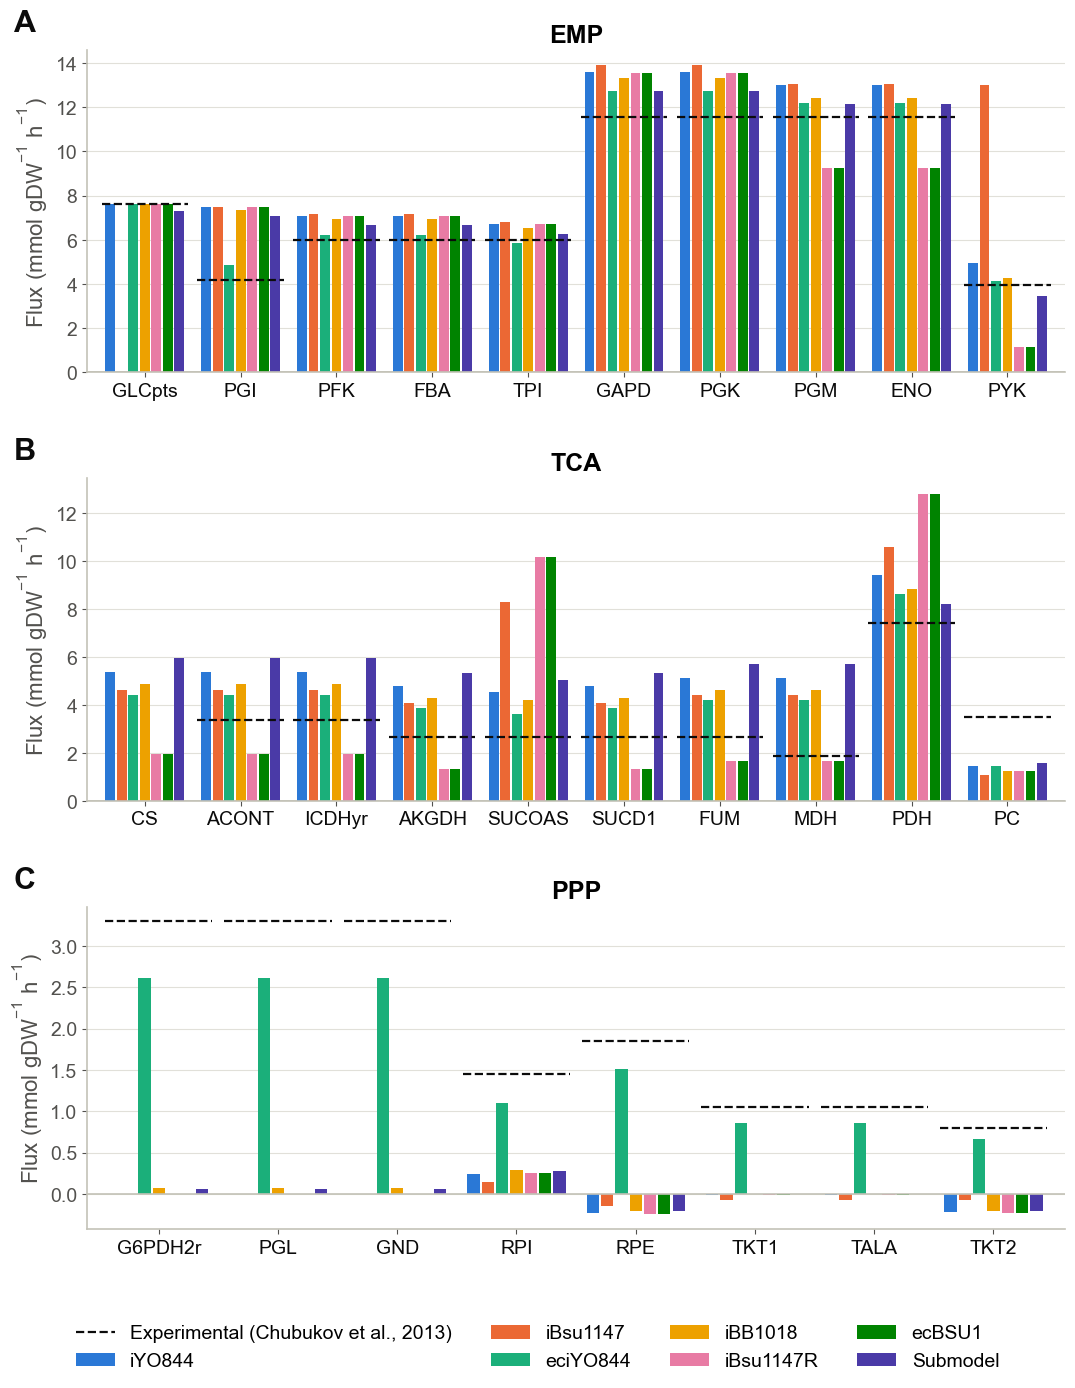

[INFO] Figure saved to ..\results\figures\carbon_metabolism_fluxes.pdf


In [6]:
figures_dir = os.path.join("..", "results", "figures")
os.makedirs(figures_dir, exist_ok=True)

# Sized for print: the panel is scaled down to one text column, so type runs large here.
plt.rcParams.update({
    "font.size": 15,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
    # the surrounding text is Arial, so one axis label ends up in two typefaces.
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#c3c2b7",
    "pdf.fonttype": 42,   # keep text as text in the PDF, not outlines
})

PANEL_LETTERS = ["A", "B", "C"]

# One colour per model, fixed across every figure in the paper and never cycled.
MODEL_COLORS = {
    "iYO844": "#2a78d6", "iBsu1147": "#eb6834", "eciYO844": "#1baf7a", "iBB1018": "#eda100",
    "iBsu1147R": "#e87ba4", "ecBSU1": "#008300", "Submodel": "#4a3aa7",
}
MUTED, GRID_COLOR = "#52514e", "#e1e0d9"

model_names = list(models.keys())
# One pathway per row, full width, so the bars stay readable and labels sit flat.
fig, axes = plt.subplots(len(PATHWAYS), 1, figsize=(11, 4.6 * len(PATHWAYS)))

for panel_letter, (ax, (pathway, rxn_ids)) in zip(PANEL_LETTERS, zip(axes, PATHWAYS.items())):
    sub = flux_df[flux_df["pathway"] == pathway]
    x = np.arange(len(rxn_ids))
    # Leave a hairline gap between neighbouring bars instead of butting them together
    slot = 0.84 / len(model_names)
    bar_width = slot * 0.86

    for i, model_name in enumerate(model_names):
        values = [sub[(sub["model"] == model_name) & (sub["reaction"] == rid)]["flux"].iloc[0]
                  for rid in rxn_ids]
        offset = (i - (len(model_names) - 1) / 2) * slot
        ax.bar(x + offset, values, bar_width, label=model_name, color=MODEL_COLORS[model_name],
               linewidth=0, zorder=3)

    # Experimental flux is per-reaction: a tick spanning each bar group, not a full line.
    exp_plotted = False
    for xi, rid in zip(x, rxn_ids):
        exp_val = EXPERIMENTAL_FLUXES.get(rid)
        if exp_val is None:
            continue
        ax.hlines(exp_val, xi - 0.45, xi + 0.45, color="#0b0b0b", linewidth=1.6, linestyle="--",
                  label="Experimental (Chubukov et al., 2013)" if not exp_plotted else None,
                  zorder=6)
        exp_plotted = True

    ax.axhline(0, color="#c3c2b7", linewidth=1.2, zorder=4)
    ax.set_title(pathway, fontweight="bold")
    # Panel letter outside the axes at the top-left, the usual journal convention
    ax.text(-0.075, 1.04, panel_letter, transform=ax.transAxes, fontfamily="Arial",
            fontsize=22, fontweight="bold", ha="left", va="bottom", color="#0b0b0b")
    ax.set_ylabel(r"Flux (mmol gDW$^{-1}$ h$^{-1}$)")
    ax.set_xticks(x)
    ax.set_xticklabels(rxn_ids)
    ax.set_xlim(-0.6, len(rxn_ids) - 0.4)
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED)
    ax.yaxis.label.set_color(MUTED)
    for label in ax.get_xticklabels():
        label.set_color("#0b0b0b")

handles, labels = [], []
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.tight_layout(h_pad=2.2)
# Legend below the stack, in one row - placed after tight_layout so it isn't squeezed into it
fig.subplots_adjust(bottom=0.10)
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.015), frameon=False,
           ncol=4)

figure_path = os.path.join(figures_dir, "carbon_metabolism_fluxes.pdf")
plt.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"[INFO] Figure saved to {figure_path}")

## Agreement with the experimental fluxes

Lin's concordance correlation coefficient against the measured fluxes, matching the statistic used for growth rates in `04_heatmaps.ipynb`.

Scored over 20 of the 28 reactions: one per stoichiometrically linked chain (the rest are forced to the same value), excluding `GLCpts` (an imposed condition, and absent from iBsu1147) and `CS` (no measured value). Fluxes are normalised to each model's realised glucose uptake. Reported pooled and per pathway.

Outputs: `../results/tables/carbon_metabolism_flux_metrics.csv` and `../results/figures/carbon_metabolism_flux_metrics.pdf`.

In [7]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error


def concordance_correlation_coefficient(y_true, y_pred):
    """Lin's CCC. Same implementation as 04_heatmaps.ipynb, deliberately - the growth-rate and
    flux analyses must report the same statistic for their numbers to be comparable."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    r, _ = pearsonr(y_true, y_pred)
    return (2 * r * sd_true * sd_pred) / (var_true + var_pred + (mean_true - mean_pred) ** 2)


# Only the first member of each chain is independent; derived from LINEAR_CHAINS so the two
# cannot drift apart.
CHAIN_DUPLICATES = {rid for chain in LINEAR_CHAINS for rid in chain[1:]}

# GLCpts is the imposed condition, not a prediction; CS has no measured value.
SCORED_REACTIONS = [rid for rid in pathways_df["ID"]
                    if rid not in CHAIN_DUPLICATES
                    and rid != "GLCpts"
                    and EXPERIMENTAL_FLUXES.get(rid) is not None]
REACTION_PATHWAY = dict(zip(pathways_df["ID"], pathways_df["pathway"]))

# Fluxes as a percentage of the glucose taken up: the experimental series against the uptake
# Chubukov et al. report, each model against the uptake it actually realised.
exp_norm = {rid: 100 * EXPERIMENTAL_FLUXES[rid] / GLUCOSE_UPTAKE for rid in SCORED_REACTIONS}

metric_records = []
for name in MODELS:
    uptake = GLUCOSE_UPTAKE_REALISED[name]
    obs = np.array([exp_norm[rid] for rid in SCORED_REACTIONS])
    pred = np.array([100 * float(lookup[(name, rid)]) / uptake for rid in SCORED_REACTIONS])

    record = {
        "Model": name,
        "n": len(SCORED_REACTIONS),
        "CCC": concordance_correlation_coefficient(obs, pred),
        "NRMSE": np.sqrt(mean_squared_error(obs, pred)),
        "MAE": mean_absolute_error(obs, pred),
        "Bias": np.mean(pred - obs),
        "Spearman_rho": spearmanr(obs, pred).statistic,
    }
    for pathway in PATHWAYS:
        subset = [rid for rid in SCORED_REACTIONS if REACTION_PATHWAY[rid] == pathway]
        record[f"CCC_{pathway}"] = concordance_correlation_coefficient(
            [exp_norm[rid] for rid in subset],
            [100 * float(lookup[(name, rid)]) / uptake for rid in subset],
        )
        record[f"n_{pathway}"] = len(subset)
    metric_records.append(record)

metrics_df = pd.DataFrame(metric_records).set_index("Model")

metrics_path = os.path.join(tables_dir, "carbon_metabolism_flux_metrics.csv")
metrics_df.to_csv(metrics_path)

counts = " / ".join(f"{metrics_df[f'n_{p}'].iloc[0]} {p}" for p in PATHWAYS)
print(f"[INFO] scored on {len(SCORED_REACTIONS)} independent reactions ({counts})")
print(f"       excluded: GLCpts (imposed condition), CS (no measured value), "
      f"{len(CHAIN_DUPLICATES)} chain duplicates")
print(f"[INFO] metrics written to {metrics_path}\n")
print("NRMSE, MAE and Bias are in % of the glucose uptake rate.")
print(metrics_df.drop(columns=[c for c in metrics_df.columns if c.startswith("n")])
      .sort_values("CCC", ascending=False).round(3).to_string())


# Check the magnitude-based scores agree on the order. Rounded first, so the ecBSU1/iBsu1147R
# tie is not broken arbitrarily.
def ranking(column, ascending):
    ranks = metrics_df[column].round(3).rank(ascending=ascending, method="min")
    return tuple(ranks.loc[MODELS])


magnitude_ranks = {"CCC": ranking("CCC", False), "NRMSE": ranking("NRMSE", True),
                   "MAE": ranking("MAE", True)}
ordered = list(metrics_df["CCC"].sort_values(ascending=False).index)
if len(set(magnitude_ranks.values())) == 1:
    print(f"\n[OK] CCC, NRMSE and MAE agree on the ranking (ties preserved):"
          f"\n     {' > '.join(ordered)}")
else:
    print("\n[CHECK] the magnitude metrics disagree - report the disagreement, don't pick one:")
    for metric_name in magnitude_ranks:
        order = metrics_df[metric_name].sort_values(ascending=metric_name != "CCC").index
        print(f"  {metric_name:<6s} {' > '.join(order)}")

# Spearman scores order only, so it is reported separately rather than as a fourth ranking metric.
spearman_order = list(metrics_df["Spearman_rho"].sort_values(ascending=False).index)
if spearman_order == ordered:
    print("\n[OK] Spearman (rank-only) agrees with the magnitude ranking.")
else:
    print(f"\n[NOTE] Spearman (rank-only) orders them differently:"
          f"\n     {' > '.join(spearman_order)}")
    moved = [m for m in MODELS if abs(spearman_order.index(m) - ordered.index(m)) >= 2]
    if moved:
        print(f"     shifted by 2+ places: {', '.join(moved)} - ranks the pathway activity in"
              f" roughly\n     the right order while getting the magnitudes wrong")

[INFO] scored on 20 independent reactions (6 EMP / 8 TCA / 6 PPP)
       excluded: GLCpts (imposed condition), CS (no measured value), 6 chain duplicates
[INFO] metrics written to ..\results\tables\carbon_metabolism_flux_metrics.csv

NRMSE, MAE and Bias are in % of the glucose uptake rate.
             CCC   NRMSE     MAE    Bias  Spearman_rho  CCC_EMP  CCC_TCA  CCC_PPP
Model                                                                            
eciYO844   0.947  13.695  10.861   5.453         0.882    0.983    0.664    0.893
iBB1018    0.873  23.316  20.930   5.417         0.862    0.886    0.546    0.021
iYO844     0.846  26.482  24.438   8.968         0.867    0.860    0.459    0.010
Submodel   0.807  29.354  25.810  10.349         0.846    0.886    0.255    0.019
ecBSU1     0.751  35.589  27.763  -1.540         0.786    0.791    0.449    0.010
iBsu1147R  0.751  35.589  27.763  -1.541         0.786    0.791    0.449    0.010
iBsu1147   0.714  39.884  31.144  15.234         0.83

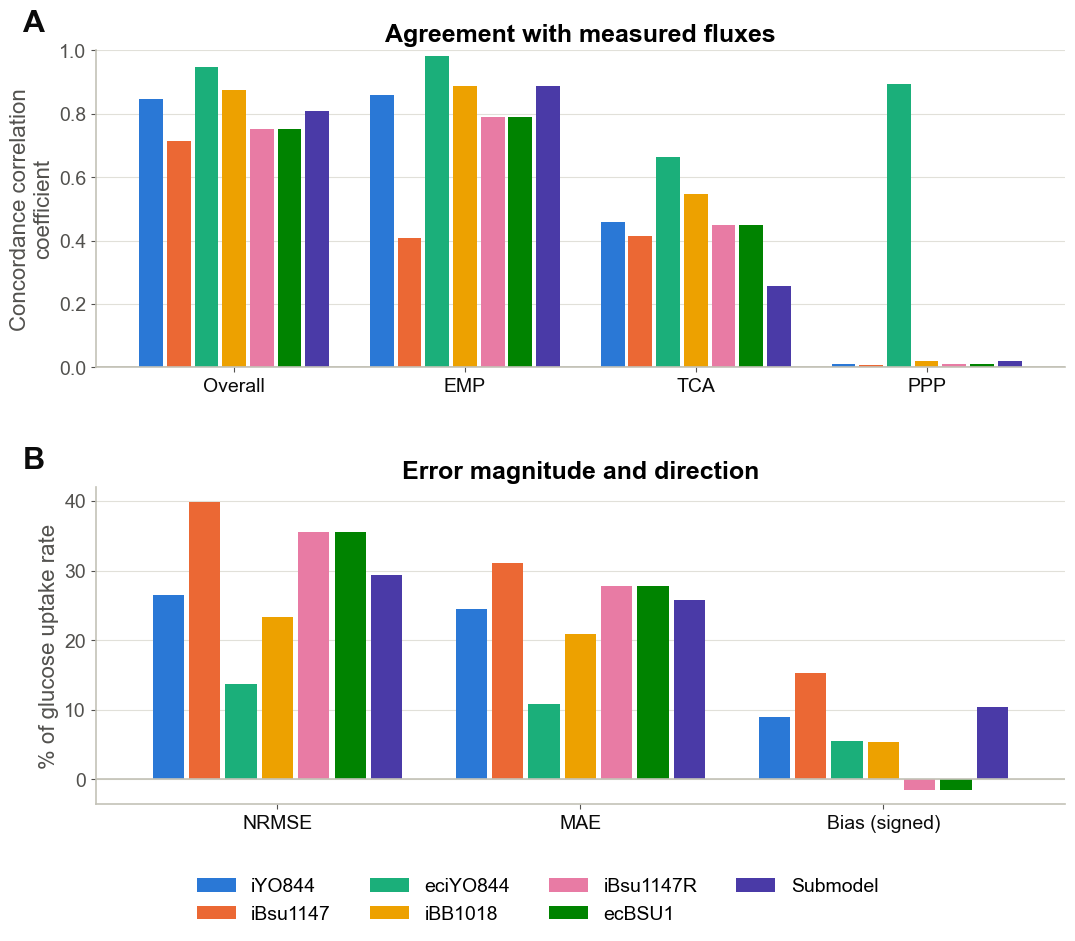

[INFO] Figure saved to ..\results\figures\carbon_metabolism_flux_metrics.pdf


In [8]:
# Supplementary figure: the metrics behind the ranking, kept out of the main flux figure.
fig, (ax_ccc, ax_err) = plt.subplots(2, 1, figsize=(11, 9.4))

slot = 0.84 / len(MODELS)
bar_width = slot * 0.86


def grouped_bars(ax, columns, labels):
    x = np.arange(len(columns))
    for i, name in enumerate(MODELS):
        values = [metrics_df.loc[name, column] for column in columns]
        offset = (i - (len(MODELS) - 1) / 2) * slot
        ax.bar(x + offset, values, bar_width, label=name, color=MODEL_COLORS[name],
               linewidth=0, zorder=3)
    ax.axhline(0, color="#c3c2b7", linewidth=1.2, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.6, len(columns) - 0.4)
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED)
    ax.yaxis.label.set_color(MUTED)
    for label in ax.get_xticklabels():
        label.set_color("#0b0b0b")


grouped_bars(ax_ccc, ["CCC"] + [f"CCC_{p}" for p in PATHWAYS], ["Overall"] + list(PATHWAYS))
ax_ccc.set_ylabel("Concordance correlation\ncoefficient")
ax_ccc.set_ylim(0, 1.0)
ax_ccc.set_title("Agreement with measured fluxes", fontweight="bold")

grouped_bars(ax_err, ["NRMSE", "MAE", "Bias"], ["NRMSE", "MAE", "Bias (signed)"])
ax_err.set_ylabel("% of glucose uptake rate")
ax_err.set_title("Error magnitude and direction", fontweight="bold")

for panel_letter, ax in zip(["A", "B"], (ax_ccc, ax_err)):
    ax.text(-0.075, 1.04, panel_letter, transform=ax.transAxes, fontfamily="Arial",
            fontsize=22, fontweight="bold", ha="left", va="bottom", color="#0b0b0b")

fig.tight_layout(h_pad=3.0)
fig.subplots_adjust(bottom=0.13)
handles, labels = ax_ccc.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.015), frameon=False,
           ncol=4)

metrics_figure_path = os.path.join(figures_dir, "carbon_metabolism_flux_metrics.pdf")
plt.savefig(metrics_figure_path, bbox_inches="tight")
plt.show()
print(f"[INFO] Figure saved to {metrics_figure_path}")